# LFBOT End-to-End Simulation

---

*Runs After*: `../notebooks/main.ipynb` (and its own upstream notebooks: `fov.ipynb`,
`skygrid.ipynb`, `skyblocks.ipynb`)
*Runs Before*: None

This notebook runs a full Monte Carlo simulation of luminous fast blue optical transients
(LFBOTs) observed by UVEX against the 3-year fiducial survey schedule
(`3_year_example_survey/initial-survey.ecsv`, produced by `main.ipynb`), using
`uvex_transient_toolkit.simulation`:

1. **Load** the fiducial schedule into a `SurveySchedule`.
2. **Sample** a Monte Carlo LFBOT population over the schedule's own sky footprint and time span
   (`SurveySimulator.generate_events`).
3. **Screen** that population down in two progressively more expensive passes:
   `filter_by_limiting_magnitude` (cheap, never touches the schedule) then `filter_by_snr`
   (consults the real schedule: is this event ever actually detected above a given SNR at an
   observation that really happened?).
4. **Inspect** the result: a detection funnel, the sky/redshift distribution of detected events,
   and a handful of individual light curves reconstructed via `Event.simulate_photometry`.


In [8]:
%xmode minimal
%load_ext autoreload
%autoreload 2

Exception reporting mode: Minimal
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [9]:
# ========================================= #
# Manage Warnings                           #
# ========================================= #
import warnings

warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
warnings.filterwarnings("ignore", ".*dubious year.*")
warnings.filterwarnings(
    "ignore", "Tried to get polar motions for times after IERS data is valid.*"
)

In [10]:
# ========================================= #
# Imports                                   #
# ========================================= #
from pathlib import Path

import numpy as np
from astropy import units as u
from ligo.skymap import plot  # noqa: F401 (registers the "astro ..." projections)
from matplotlib import pyplot as plt
from regions import Regions

from astropy.table import QTable
from m4opt.missions._uvex import uvex
from uvex_transient_toolkit.models.core.priors import LogNormalPrior, NormalPrior
from uvex_transient_toolkit.simulation.core import SurveySimulator
from uvex_transient_toolkit.surveys.base import SurveySchedule
from uvex_transient_toolkit.transients.LFBOTs import LuminousFastBlueOpticalTransient

### Configuration Settings

In [11]:
# ========================================= #
# Settings and Configuration                #
# ========================================= #

# --- SURVEY INPUT SETTINGS --- #
# Directory containing the 3-year fiducial survey products written by ``../notebooks/main.ipynb``
# (and its own upstream notebooks) in this repository.
SURVEY_OUTPUT_PATH = Path("../preliminary_survey")
PLAN_FILE_PATH = SURVEY_OUTPUT_PATH / "initial-survey.ecsv"
# ``SurveySchedule`` only supports a Rectangle/CircleSkyRegion FOV (not the real chip-gapped
# footprint ``main.ipynb`` schedules against) -- the bounding rectangle is the appropriately
# conservative single-shape approximation for the containment queries this notebook needs
# (``SurveySchedule.get_observations_of``).
FOV_FILE_PATH = SURVEY_OUTPUT_PATH / "bounding-rectangle.ds9"

# --- OUTPUT SETTINGS --- #
OUTPUT_PATH = SURVEY_OUTPUT_PATH / "transients"
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)

# --- POPULATION SETTINGS --- #
# HEALPix resolution and number of time bins ``generate_events`` samples over -- see its own
# docstring. This same NSIDE is also what ``filter_by_snr`` below queries its schedule
# coverage index at (it reuses each event's own ``healpix_id`` directly, at whatever
# resolution it was sampled at -- see that method's docstring), so it needs to be fine
# enough relative to UVEX's ~3.7 deg FOV that pixel-center-membership tracks true FOV
# containment closely: NSIDE=128 (~0.46 deg pixels, ~8x finer than the FOV) keeps that
# approximation to roughly a 0.6% chance of a wrong detect/non-detect decision, split
# roughly evenly between false positives and false negatives. Higher NSIDE / more
# TIME_BINS sample a more complete population at the cost of runtime.
NSIDE = 128
TIME_BINS = 200
SIMULATION_SEED = 42

# --- SCREENING SETTINGS --- #
# AB magnitude limit for the cheap, schedule-agnostic first pass (``filter_by_limiting_magnitude``).
MAG_LIMIT = 25.0
MAG_FILTER_CHUNK_SIZE = 5000

# SNR an event must clear at least once, at some real scheduled observation, to count as
# detected (``filter_by_snr``).
SNR_THRESHOLD = 5.0
SNR_FILTER_CHUNK_SIZE = 500

# --- LFBOT SED PRIOR SETTINGS --- #
# Direct control over the LFBOT population's physical parameter priors, so they can be
# reshaped here without editing `LFBOTCoolingBlackbodySED` itself. Each entry is
# `(prior_class, prior_kwargs, scale)`, mirroring that class's own `_DEFAULT_PARAMETERS`
# -- see its docstring for what each parameter means physically and for the Ho & Lu et al.
# 2026 values these defaults already encode. Left as-is, this reproduces the model's
# defaults exactly; edit any entry (or add new ones) to explore a different population.
#
# `mean`/`sigma` are in the prior's own latent-variable units: log10 for `amplitude`
# (`NormalPrior`, since `amplitude` uses `transform="log10"`), natural log for every other
# parameter (`LogNormalPrior`, the untransformed default) -- see `Parameter.transform`.
# `scale` is the corresponding physical characteristic value.
# LFBOT_PRIOR_OVERRIDES = {
#     "amplitude": (NormalPrior, dict(mean=44.65, sigma=0.01), 1.0 * u.erg / u.s),
#     "t_peak": (LogNormalPrior, dict(mean=0.0, sigma=0.01), 10.0 * u.day),
#     "decline_index": (LogNormalPrior, dict(mean=0.0, sigma=0.01), 3.0),
#     "T0": (LogNormalPrior, dict(mean=0.0, sigma=0.01), 2e4 * u.K),
#     "T_floor": (LogNormalPrior, dict(mean=0.0, sigma=0.01), 1.2e4 * u.K),
#     "alpha_T": (LogNormalPrior, dict(mean=0.0, sigma=0.01), 1.0 / 3.0),
# }

# --- EXAMPLE LIGHT CURVE SETTINGS --- #
N_EXAMPLE_LIGHTCURVES = 10
EXAMPLE_SEED = 0

## Load the Survey Schedule

Reads the fiducial 3-year schedule directly -- its columns (`start_time`, `duration`,
`observer_location`, `action`, `target_coord`, `roll`, `field_id`, `block_id`) already match
`SurveySchedule`'s expected schema, so no conversion is needed.

In [12]:
# ========================================= #
# Load the 3-Year Fiducial Survey Schedule  #
# ========================================= #
for _path in (PLAN_FILE_PATH, FOV_FILE_PATH):
    if not _path.exists():
        raise FileNotFoundError(
            f"File not found at {_path}. Run ../notebooks/main.ipynb (and its own upstream "
            "notebooks) first."
        )

plan = QTable.read(PLAN_FILE_PATH)
(fov,) = Regions.read(str(FOV_FILE_PATH))
schedule = SurveySchedule(plan, fov)

n_observe = int(np.count_nonzero(plan["action"] == "observe"))
print(f"{len(schedule)} scheduled actions ({n_observe} observations)")
print(
    f"Mission span: {schedule.start_time.iso} to "
    f"{(schedule.start_time + schedule.duration).iso}"
)

69663 scheduled actions (33010 observations)
Mission span: 2030-01-01 00:00:00.000 to 2032-01-01 06:10:40.983


## Set Up the LFBOT Population

`LuminousFastBlueOpticalTransient` supplies both the SED model (`LFBOTCoolingBlackbodySED`) and
the volumetric event rate `SurveySimulator.generate_events` samples from -- a constant 10
Gpc^-3 yr^-1 (Perley et al. 2026; Ho & Lu et al. 2026) out to z=4. `SurveySimulator` ties it to
the schedule loaded above.


In [19]:
# ========================================= #
# Register the LFBOT Population               #
# ========================================= #
lfbot = LuminousFastBlueOpticalTransient()

# Set the basic parameters.
lfbot.redshift_limit = 4

simulator = SurveySimulator(schedule, transients={"lfbot": lfbot}, simulation_seed=SIMULATION_SEED)


(1e+41, 1e+45)

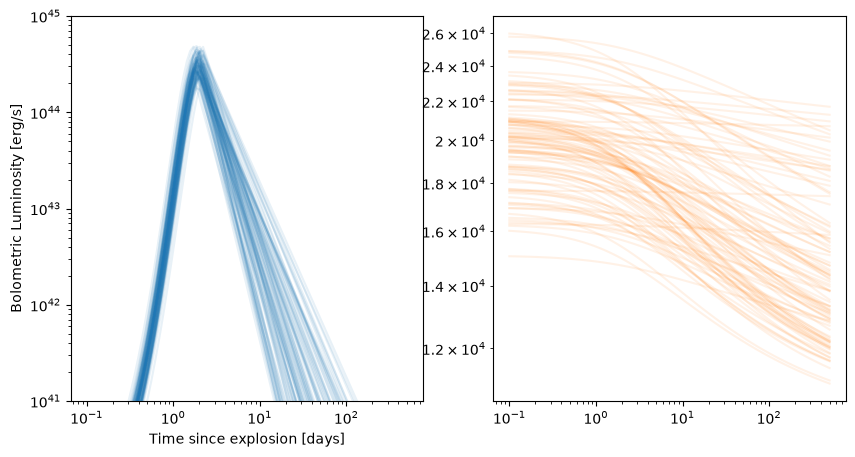

In [20]:
# Sample 100 random events and show their bolometric light curves, to sanity-check the population's shape.
_rng = np.random.default_rng(0)
t = np.geomspace(1e-1, 500, 100) * u.day
fig, axes = plt.subplots(nrows=1, ncols=2, sharex=True, sharey=False, figsize=(10, 5))

parameters = lfbot.sed.sample_parameters(1000,rng=_rng)
L = lfbot.sed.eval_bolometric(t[:,np.newaxis],**parameters)
T = lfbot.sed.temperature(t[:,np.newaxis],**parameters)

for i in range(100):
    axes[0].plot(t, L[:,i], color="C0", alpha=0.1)
    axes[1].plot(t, T[:,i], color="C1", alpha=0.1)
axes[0].set_yscale("log")
axes[0].set_xscale("log")
axes[1].set_yscale("log")
axes[0].set_xlabel("Time since explosion [days]")
axes[0].set_ylabel("Bolometric Luminosity [erg/s]")

axes[0].set_ylim([1e41,1e45])


## Sample a Monte Carlo LFBOT Population

`generate_events` samples explosion times, positions, redshifts, and per-event physical
parameter seeds only within the HEALPix pixels and time bins the survey could plausibly have
caught an event in -- see its own docstring for exactly how `luminosity_distance`/`ebv` get
cached here too.


In [21]:
# ========================================= #
# Sample a Monte Carlo LFBOT Population        #
# ========================================= #
catalog = simulator.generate_events(time_bins=TIME_BINS, nside=NSIDE)
print(f"Sampled {len(catalog)} LFBOTs across {TIME_BINS} time bin(s) at NSIDE={NSIDE}.")

Generating events: 100%|██████████| 200/200 [00:15<00:00, 12.58bin/s, bin=200/200, type=lfbot]


Sampled 2861 LFBOTs across 200 time bin(s) at NSIDE=128.


## Screen: Ever Bright Enough?

`filter_by_limiting_magnitude` never touches the schedule -- it only asks whether an event could
ever clear `MAG_LIMIT` over its own duration, using a shared phase grid. A freshly sampled
catalog is typically dominated by events far too faint to ever matter, so this cheap pass runs
first.

In [22]:
# ========================================= #
# Screen: Ever Bright Enough?                 #
# ========================================= #
mag_filtered = simulator.filter_by_limiting_magnitude(
    catalog,
    uvex,
    mag_limit=MAG_LIMIT,
    chunk_size=MAG_FILTER_CHUNK_SIZE,
)
print(f"{len(mag_filtered)} of {len(catalog)} LFBOTs could ever clear {MAG_LIMIT} AB mag.")

Filtering by mag limit: 100%|██████████| 1/1 [00:00<00:00,  1.21chunk/s, chunk=1/1, type=lfbot]

585 of 2861 LFBOTs could ever clear 25.0 AB mag.


## Screen: Actually Detected by the Schedule?

`filter_by_snr` asks the real question: over every observation the schedule actually made of an
event's position while it was active, is it ever detected above `SNR_THRESHOLD`? Unlike the
magnitude cut above, this *does* consult the schedule -- via a fast HEALPix-pixel coverage index
(`SurveySchedule.get_observations_of_healpix`) built once, on first use, and cached: about a
second to index the whole 3-year schedule, then a cheap lookup per event, queried at each event's
own `healpix_id` -- the same grid `NSIDE` samples the population on (see the config cell above for
why that resolution matters here too). That index trades a small amount of geometric precision for
speed -- pixel-*center* membership rather than exact FOV polygon containment -- so a small fraction
of events (roughly 0.6% at `NSIDE=128`) end up with a different detect/non-detect decision than the
exact geometric test would give, split roughly evenly between false positives and false negatives.


In [23]:
# ========================================= #
# Screen: Actually Detected by the Schedule?  #
# ========================================= #
detected = simulator.filter_by_snr(
    mag_filtered,
    uvex,
    snr_threshold=SNR_THRESHOLD,
    chunk_size=SNR_FILTER_CHUNK_SIZE,
)
print(f"{len(detected)} of {len(mag_filtered)} LFBOTs were detected above SNR={SNR_THRESHOLD}.")

Filtering by SNR: 100%|██████████| 2/2 [00:01<00:00,  1.80chunk/s, chunk=2/2, type=lfbot]

32 of 585 LFBOTs were detected above SNR=5.0.


## Detection Summary

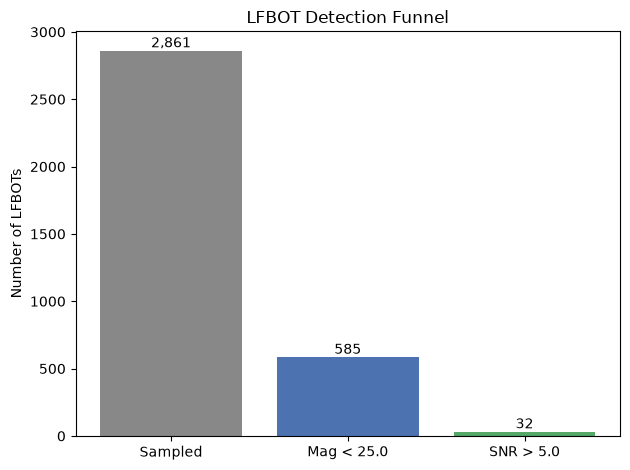

In [24]:
# ========================================= #
# Detection Funnel                            #
# ========================================= #
_stages = ["Sampled", f"Mag < {MAG_LIMIT}", f"SNR > {SNR_THRESHOLD}"]
_counts = [len(catalog), len(mag_filtered), len(detected)]

fig, ax = plt.subplots()
ax.bar(_stages, _counts, color=["#888888", "#4C72B0", "#55A868"])
for i, c in enumerate(_counts):
    ax.text(i, c, f"{c:,}", ha="center", va="bottom")
ax.set_ylabel("Number of LFBOTs")
ax.set_title("LFBOT Detection Funnel")
fig.tight_layout()

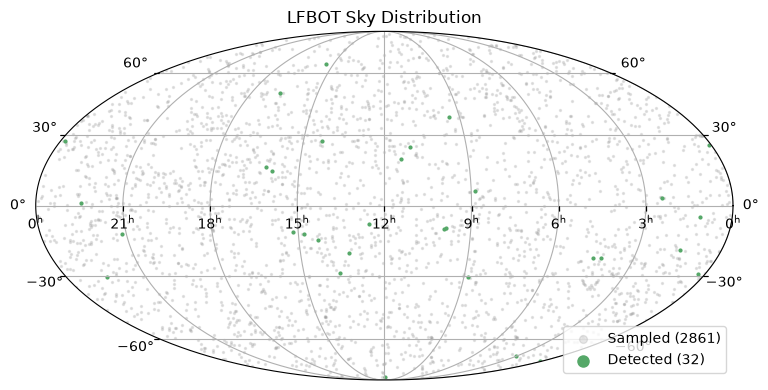

In [25]:
# ========================================= #
# Sky Distribution                            #
# ========================================= #
fig = plt.figure(figsize=(8, 4))
ax = fig.add_subplot(projection="astro hours mollweide")
ax.grid()
_transform = ax.get_transform("world")
ax.scatter(
    catalog.coord.ra.deg,
    catalog.coord.dec.deg,
    transform=_transform,
    s=2,
    alpha=0.2,
    color="#888888",
    label=f"Sampled ({len(catalog)})",
)
ax.scatter(
    detected.coord.ra.deg,
    detected.coord.dec.deg,
    transform=_transform,
    s=4,
    color="#55A868",
    label=f"Detected ({len(detected)})",
)
ax.legend(loc="lower right", markerscale=4)
ax.set_title("LFBOT Sky Distribution")
fig.tight_layout()

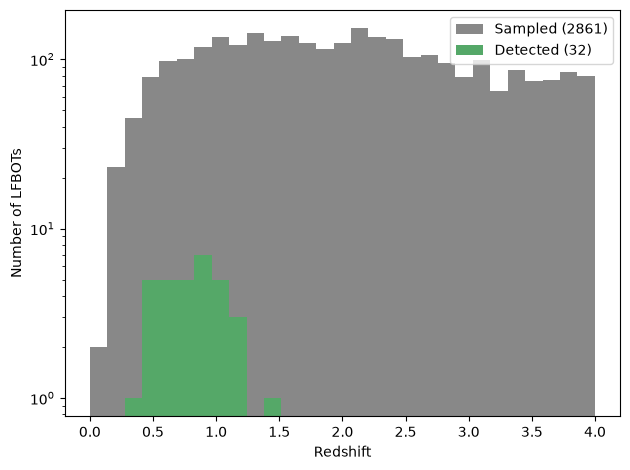

In [26]:
# ========================================= #
# Redshift Distribution                       #
# ========================================= #
_bins = np.linspace(0, catalog.redshift.max(), 30)
fig, ax = plt.subplots()
ax.hist(catalog.redshift, bins=_bins, color="#888888", label=f"Sampled ({len(catalog)})")
ax.hist(detected.redshift, bins=_bins, color="#55A868", label=f"Detected ({len(detected)})")
ax.set_yscale("log")
ax.set_xlabel("Redshift")
ax.set_ylabel("Number of LFBOTs")
ax.legend()
fig.tight_layout()

## Example Light Curves

Reconstructs a handful of detected events as real `Event` objects (`EventCatalog.get_events`)
and runs full synthetic photometry (`Event.simulate_photometry`) against every observation the
schedule actually made of each one.

In [27]:
# ========================================= #
# Reconstruct a Few Detected Events           #
# ========================================= #
_rng = np.random.default_rng(EXAMPLE_SEED)
_example_ids = _rng.choice(
    detected.event_id, size=min(N_EXAMPLE_LIGHTCURVES, len(detected)), replace=False
)
example_events = detected.get_events(_example_ids, {"lfbot": lfbot}, schedule)

for event in example_events:
    print(event)

<Event id=1358 type='lfbot' z=0.4914 n_observations=24>
<Event id=2311 type='lfbot' z=0.5024 n_observations=5>
<Event id=1088 type='lfbot' z=0.5494 n_observations=5>
<Event id=820 type='lfbot' z=0.7374 n_observations=1>
<Event id=657 type='lfbot' z=0.8894 n_observations=1>
<Event id=368 type='lfbot' z=0.5326 n_observations=4>
<Event id=284 type='lfbot' z=1.402 n_observations=3>
<Event id=668 type='lfbot' z=0.9413 n_observations=2>
<Event id=512 type='lfbot' z=0.97 n_observations=2>
<Event id=421 type='lfbot' z=1.05 n_observations=100>


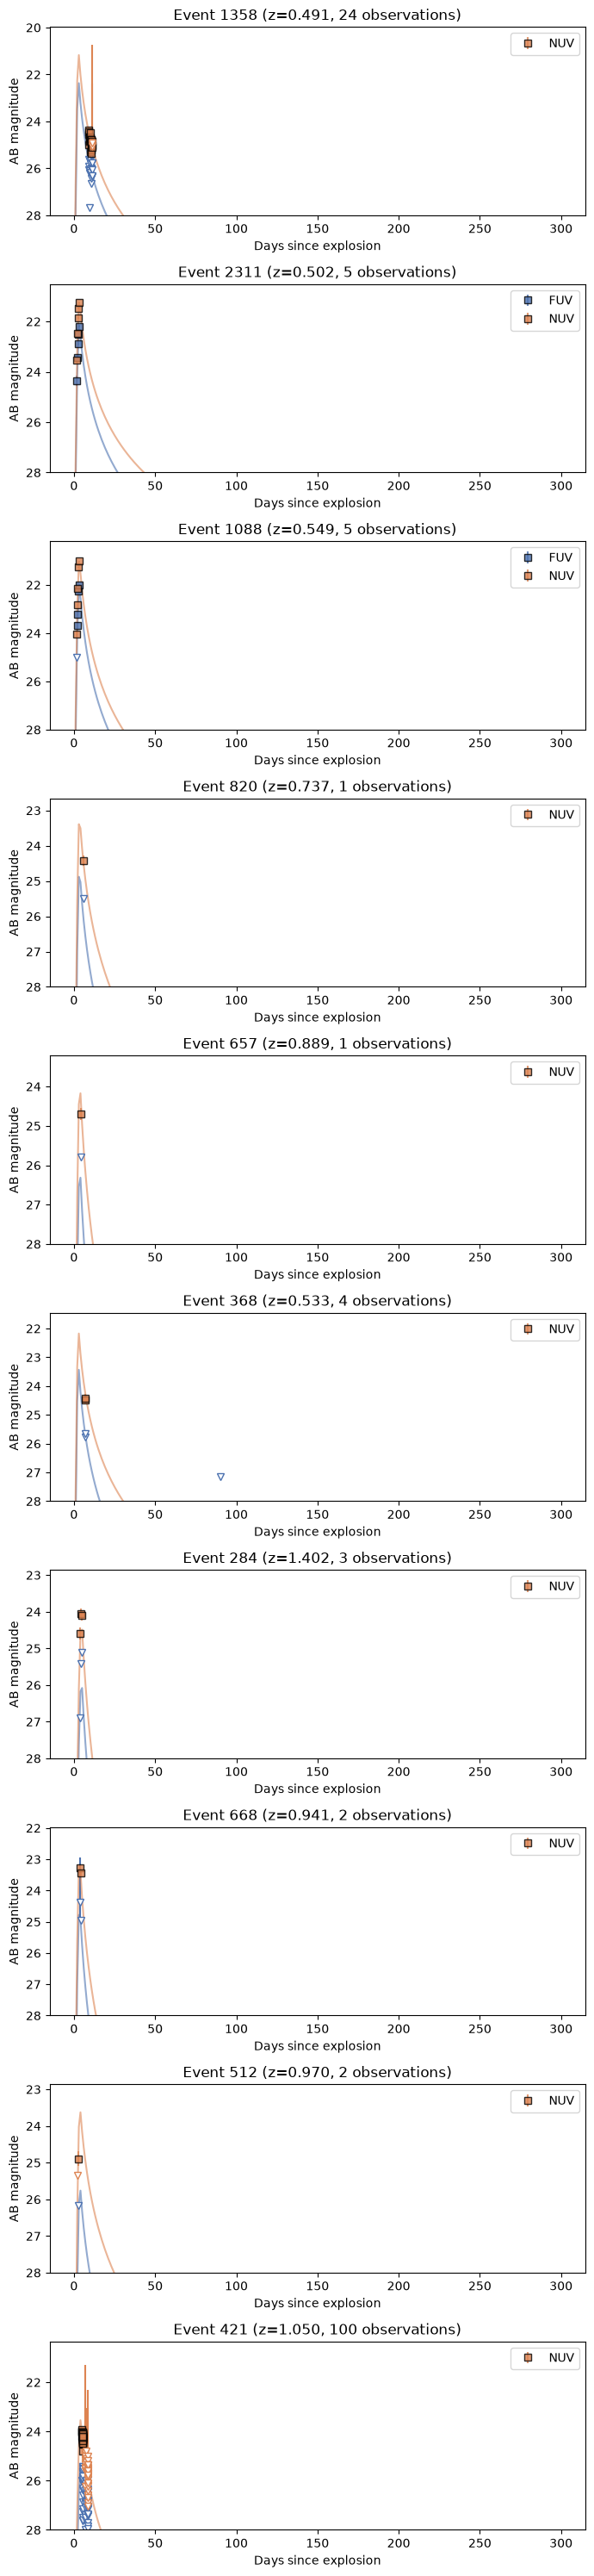

In [28]:
# ========================================= #
# Plot Light Curves                           #
# ========================================= #
_band_colors = {"FUV": "#4C72B0", "NUV": "#DD8452"}

fig, axes = plt.subplots(
    len(example_events), 1, figsize=(7, 3 * len(example_events)), squeeze=False
)
for ax, event in zip(axes[:, 0], example_events):
    phot = event.simulate_photometry(uvex)
    t_since_explosion = (phot["obs_time"] - event.t_explosion).to(u.day)

    t_array = np.linspace(0, 300, 300) * u.day

    for band, color in _band_colors.items():
        # Theory curve: the true (noiseless) magnitude vs. time -- Event.mag reuses
        # this event's own redshift/luminosity_distance/dust/SED parameters
        # automatically, and matches simulate_photometry's own noiseless mean exactly
        # (same pivot-wavelength definition, see its docstring).
        mag_theory = event.mag(t_array, uvex, band=band)
        ax.plot(t_array.value, mag_theory.value, color=color, lw=1.5, alpha=0.6)

        selected = (
            np.isfinite(phot["ab_mag"]) & (phot["band"] == band) & (phot["snr"] > 5)
        )
        non_detected = (
            np.isfinite(phot["ab_mag"]) & (phot["band"] == band) & (phot["snr"] <= 5)
        )

        # Each marker kind is only ever drawn if it actually has points -- an empty
        # `selected` (no confident detections in this band) used to `continue` past
        # the `non_detected` errorbar call below too, hiding real non-detections.
        if np.any(selected):
            ax.errorbar(
                t_since_explosion[selected].value,
                phot["ab_mag"][selected],
                yerr=phot["mag_err"][selected],
                mfc=color,
                mec="k",
                ecolor=color,
                marker="s",
                linestyle="none",
                alpha=0.8,
                label=band,
            )
        if np.any(non_detected):
            ax.errorbar(
                t_since_explosion[non_detected].value,
                phot["ab_mag"][non_detected],
                yerr=[phot["mag_upper"][non_detected] - phot["ab_mag"][non_detected],
                      np.abs(phot["mag_lower"][non_detected] - phot["ab_mag"][non_detected])],
                marker="v",
                mec=color,
                mfc="w",
                ecolor=color,
                linestyle="none",
            )

    ax.invert_yaxis()
    ax.set_xlabel("Days since explosion")
    ax.set_ylabel("AB magnitude")
    ax.set_title(
        f"Event {event.event_id} (z={event.redshift:.3f}, "
        f"{event.n_observations} observations)"
    )
    ax.legend()


for ax in axes.flatten():
    ax.set_ylim([28, None])
fig.tight_layout()
fig.savefig(OUTPUT_PATH / "lfbot_example_lightcurves.png")

## Save the Detected Catalog

In [29]:
# ========================================= #
# Save the Detected Catalog                   #
# ========================================= #
_catalog_path = OUTPUT_PATH / "lfbot_detected_catalog.ecsv"
detected.to_disk(_catalog_path, overwrite=True)
print(f"Wrote {len(detected)} detected LFBOTs to {_catalog_path}")

Wrote 32 detected LFBOTs to ../preliminary_survey/transients/lfbot_detected_catalog.ecsv
